                    PHONEPAY ANALYSIS 

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sqlalchemy import create_engine
import urllib

sql serever connection

In [14]:
# Server Name
server = r"LAPTOP-71G1NMQR\SQLEXPRESS"

# Database Name
database = "PAYMENTS_DB"

# Connection String
params = urllib.parse.quote_plus(
    f"DRIVER={{ODBC Driver 18 for SQL Server}};"
    f"SERVER={server};"
    f"DATABASE={database};"
    f"Trusted_Connection=yes;"
    f"TrustServerCertificate=yes;"
)

# Create Engine
engine = create_engine(
    f"mssql+pyodbc:///?odbc_connect={params}"
)

print("Connection Created Successfully!")

Connection Created Successfully!


In [15]:
##check the odbc driver for sql serever
import pyodbc

print(pyodbc.drivers())

['SQL Server', 'SQL Server Native Client RDA 11.0', 'ODBC Driver 18 for SQL Server', 'Microsoft Access Driver (*.mdb, *.accdb)', 'Microsoft Excel Driver (*.xls, *.xlsx, *.xlsm, *.xlsb)', 'Microsoft Access Text Driver (*.txt, *.csv)', 'Microsoft Access dBASE Driver (*.dbf, *.ndx, *.mdx)']


In [16]:
##Connection Test
query = "SELECT @@VERSION"

df = pd.read_sql(query, engine)

df

,
0,Microsoft SQL Server 2022 (RTM) - 16.0.1000.6 ...


In [20]:
###Show tha all tables in database 
query = """
SELECT TABLE_NAME
FROM INFORMATION_SCHEMA.TABLES
"""

tables = pd.read_sql(query, engine)

tables

,TABLE_NAME
0,STG_USERS
1,STG_TRANSACTIONS
2,USERS_CLEAN
3,TRANSACTIONS_CLEAN
4,sysdiagrams
5,DIM_USERS
6,DIM_DATE
7,FACT_TRANSACTIONS


Data pull

In [22]:
##fact_transactions
fact = pd.read_sql("""

SELECT *
FROM FACT_TRANSACTIONS

""",engine)

fact.head()

,TRANSACTION_ID,USER_KEY,DATE_KEY,AMOUNT,SERVICE,SERVICE_TYPE,PAYMENT_STATUS,REASON
0,INS_0000D06483C0,18765,20240509,11289.27,Insurance,Car,Successful,Successful
1,INS_000210BAC0A0,101004,20241012,14714.69,Insurance,Bike,Successful,Successful
2,INS_0005C2CCE209,95329,20240211,19654.73,Insurance,Health,Successful,Successful
3,INS_000627A4165C,46793,20240512,10699.79,Insurance,Term Life,Successful,Successful
4,INS_00095A2BB92D,75544,20240817,10750.95,Insurance,Car,Successful,Successful


In [23]:
##dim_users
users = pd.read_sql("""

SELECT *
FROM DIM_USERS

""",engine)

users.head()

,USER_KEY,USER_ID,USER_NAME,AGE,JOIN_DATE
0,1,PP0000001,Holly Rivera,56,2025-06-17
1,2,PP0000002,Kevin Lopez,46,2023-12-10
2,3,PP0000003,Douglas Roberts,32,2024-09-14
3,4,PP0000004,Walter Davila,60,2023-10-19
4,5,PP0000005,Grace Blake,25,2025-03-10


In [24]:
##dim_date
dates = pd.read_sql("""

SELECT *
FROM DIM_DATE

""",engine)

dates.head()

,DATE_KEY,FULL_DATE,YEAR,QUARTER,MONTH_NO,MONTH_NAME,DAY_NO
0,20240101,2024-01-01,2024,1,1,January,1
1,20240102,2024-01-02,2024,1,1,January,2
2,20240103,2024-01-03,2024,1,1,January,3
3,20240104,2024-01-04,2024,1,1,January,4
4,20240105,2024-01-05,2024,1,1,January,5


In [25]:
fact.info()

<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   TRANSACTION_ID  300000 non-null  str    
 1   USER_KEY        300000 non-null  int64  
 2   DATE_KEY        300000 non-null  int64  
 3   AMOUNT          300000 non-null  float64
 4   SERVICE         300000 non-null  str    
 5   SERVICE_TYPE    300000 non-null  str    
 6   PAYMENT_STATUS  300000 non-null  str    
 7   REASON          300000 non-null  str    
dtypes: float64(1), int64(2), str(5)
memory usage: 18.3 MB


In [27]:
dates.info()

<class 'pandas.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   DATE_KEY    365 non-null    int64 
 1   FULL_DATE   365 non-null    object
 2   YEAR        365 non-null    int64 
 3   QUARTER     365 non-null    int64 
 4   MONTH_NO    365 non-null    int64 
 5   MONTH_NAME  365 non-null    str   
 6   DAY_NO      365 non-null    int64 
dtypes: int64(5), object(1), str(1)
memory usage: 20.1+ KB


In [28]:
users.info()

<class 'pandas.DataFrame'>
RangeIndex: 107658 entries, 0 to 107657
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   USER_KEY   107658 non-null  int64 
 1   USER_ID    107658 non-null  str   
 2   USER_NAME  107658 non-null  str   
 3   AGE        107658 non-null  int64 
 4   JOIN_DATE  107658 non-null  object
dtypes: int64(2), object(1), str(2)
memory usage: 4.1+ MB


Shape check

In [30]:
fact.shape

(300000, 8)

In [31]:
users.shape

(107658, 5)

In [32]:
dates.shape

(365, 7)

Null Values check

In [33]:
fact.isnull().sum()

TRANSACTION_ID    0
USER_KEY          0
DATE_KEY          0
AMOUNT            0
SERVICE           0
SERVICE_TYPE      0
PAYMENT_STATUS    0
REASON            0
dtype: int64

In [34]:
users.isnull().sum()

USER_KEY     0
USER_ID      0
USER_NAME    0
AGE          0
JOIN_DATE    0
dtype: int64

In [36]:
dates.isnull().sum()

DATE_KEY      0
FULL_DATE     0
YEAR          0
QUARTER       0
MONTH_NO      0
MONTH_NAME    0
DAY_NO        0
dtype: int64

Duplicate Check

In [37]:
fact.duplicated().sum()

np.int64(0)

In [38]:
users.duplicated().sum()

np.int64(0)

In [39]:
dates.duplicated().sum()

np.int64(0)

Unique Check

In [40]:
fact["TRANSACTION_ID"].nunique()

300000

In [41]:
users["USER_ID"].nunique()

107658

In [45]:
fact["SERVICE"].nunique()

4

In [46]:
fact["SERVICE_TYPE"].nunique()

16

Data Type Conversion

In [47]:
dates["FULL_DATE"]=pd.to_datetime(
    dates["FULL_DATE"]
)

In [48]:
users["JOIN_DATE"]=pd.to_datetime(
    users["JOIN_DATE"]
)

In [49]:
dates["FULL_DATE"].dtypes

dtype('<M8[s]')

In [50]:
users["JOIN_DATE"].dtypes

dtype('<M8[s]')

1: Primary Key Check

In [53]:
# Users Table
users["USER_KEY"].nunique()
users["USER_KEY"].duplicated().sum()

np.int64(0)

In [54]:
# Dates Table
dates["DATE_KEY"].nunique()
dates["DATE_KEY"].duplicated().sum()

np.int64(0)

2: Foreign Key Validation

In [57]:
# USER_KEY validation
fact["USER_KEY"].isin(users["USER_KEY"]).all()


np.True_

In [58]:
# DATE_KEY validation
fact["DATE_KEY"].isin(dates["DATE_KEY"]).all()

np.True_

            First Merge

In [59]:
df = fact.merge(
    users,
    on="USER_KEY",
    how="left"
)

df.shape

(300000, 12)

            Second Merge

In [60]:
df = df.merge(
    dates,
    on="DATE_KEY",
    how="left"
)

df.shape

(300000, 18)

        check merge data

In [62]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype        
---  ------          --------------   -----        
 0   TRANSACTION_ID  300000 non-null  str          
 1   USER_KEY        300000 non-null  int64        
 2   DATE_KEY        300000 non-null  int64        
 3   AMOUNT          300000 non-null  float64      
 4   SERVICE         300000 non-null  str          
 5   SERVICE_TYPE    300000 non-null  str          
 6   PAYMENT_STATUS  300000 non-null  str          
 7   REASON          300000 non-null  str          
 8   USER_ID         300000 non-null  str          
 9   USER_NAME       300000 non-null  str          
 10  AGE             300000 non-null  int64        
 11  JOIN_DATE       300000 non-null  datetime64[s]
 12  FULL_DATE       300000 non-null  datetime64[s]
 13  YEAR            300000 non-null  int64        
 14  QUARTER         300000 non-null  int64        
 15  MONTH_NO   

In [73]:
df.head()

,TRANSACTION_ID,USER_KEY,DATE_KEY,AMOUNT,SERVICE,SERVICE_TYPE,PAYMENT_STATUS,REASON,USER_ID,USER_NAME,AGE,JOIN_DATE,FULL_DATE,YEAR,QUARTER,MONTH_NO,MONTH_NAME,DAY_NO
0,INS_0000D06483C0,18765,20240509,11289.27,Insurance,Car,Successful,Successful,PP0019136,Jessica Dunn,29,2024-11-16,2024-05-09,2024,2,5,May,9
1,INS_000210BAC0A0,101004,20241012,14714.69,Insurance,Bike,Successful,Successful,PP1101003,Richard Miller,43,2025-05-22,2024-10-12,2024,4,10,October,12
2,INS_0005C2CCE209,95329,20240211,19654.73,Insurance,Health,Successful,Successful,PP1095328,Maria Mendez,29,2023-11-19,2024-02-11,2024,1,2,February,11
3,INS_000627A4165C,46793,20240512,10699.79,Insurance,Term Life,Successful,Successful,PP0047662,Benjamin Davis,59,2025-04-21,2024-05-12,2024,2,5,May,12
4,INS_00095A2BB92D,75544,20240817,10750.95,Insurance,Car,Successful,Successful,PP1075543,Dr. Stanley Bush,34,2024-10-06,2024-08-17,2024,3,8,August,17


In [81]:
df.duplicated().sum()

np.int64(0)

In [82]:
df.isnull().sum()

TRANSACTION_ID    0
USER_KEY          0
DATE_KEY          0
AMOUNT            0
SERVICE           0
SERVICE_TYPE      0
PAYMENT_STATUS    0
REASON            0
USER_ID           0
USER_NAME         0
AGE               0
JOIN_DATE         0
FULL_DATE         0
YEAR              0
QUARTER           0
MONTH_NO          0
MONTH_NAME        0
DAY_NO            0
dtype: int64

In [76]:
###cleaning data save
df.to_csv("phonepay_cleaned.csv",index=False)

In [78]:
##check save file
import os 
os.getcwd()

'C:\\Users\\SASWAT\\AppData\\Local\\Programs\\anaconda-desktop'

                                ANALYSIS PART

In [87]:
# Executive KPIs

total_revenue = round(df["AMOUNT"].sum()/1000000000,2)

total_transactions = df["TRANSACTION_ID"].nunique()

total_users = df["USER_ID"].nunique()

avg_transaction = df["AMOUNT"].mean()

max_amount = df["AMOUNT"].max()

min_amount = df["AMOUNT"].min()

median_amount = df["AMOUNT"].median()

revenue_per_user = total_revenue / total_users

revenue_per_transaction = total_revenue / total_transactions


# Print All KPIs

print("="*50)
print("EXECUTIVE KPI ANALYSIS")
print("="*50)

print(f"Total Revenue In Billion     : ₹ {total_revenue:,.2f}")
print(f"Total Transactions           : {total_transactions:,}")
print(f"Total Users                  : {total_users:,}")
print(f"Average Transaction Value    : ₹ {avg_transaction:,.2f}")
print(f"Maximum Transaction Amount   : ₹ {max_amount:,.2f}")
print(f"Minimum Transaction Amount   : ₹ {min_amount:,.2f}")
print(f"Median Transaction Amount    : ₹ {median_amount:,.2f}")
print(f"Revenue Per User             : ₹ {revenue_per_user:,.2f}")
print(f"Revenue Per Transaction      : ₹ {revenue_per_transaction:,.2f}")

print("="*50)

EXECUTIVE KPI ANALYSIS
Total Revenue In Billion     : ₹ 3.47
Total Transactions           : 300,000
Total Users                  : 100,761
Average Transaction Value    : ₹ 11,581.07
Maximum Transaction Amount   : ₹ 99,999.01
Minimum Transaction Amount   : ₹ 20.00
Median Transaction Amount    : ₹ 3,091.45
Revenue Per User             : ₹ 0.00
Revenue Per Transaction      : ₹ 0.00


In [95]:
# Total Transactions by Payment Status

print(df["PAYMENT_STATUS"].value_counts())


# Revenue

print(
df.groupby(
"PAYMENT_STATUS"
)["AMOUNT"].sum().round(2))

PAYMENT_STATUS
Successful             287993
Failed                   9980
Wrong PIN                 700
Server error              692
Insufficient amount       635
Name: count, dtype: int64
PAYMENT_STATUS
Failed                 3.931760e+07
Insufficient amount    3.222211e+07
Server error           3.455447e+07
Successful             3.333026e+09
Wrong PIN              3.520166e+07
Name: AMOUNT, dtype: float64


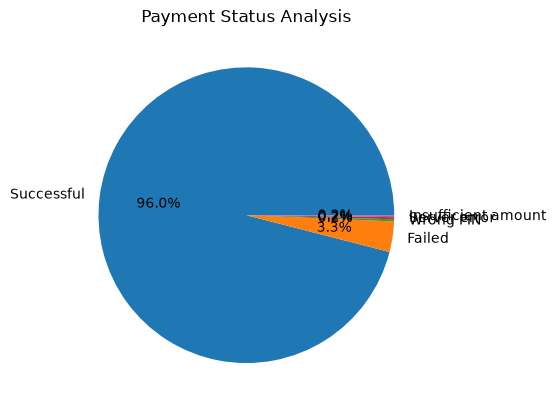

In [98]:
df["PAYMENT_STATUS"]\
.value_counts()\
.plot(
kind="pie",
autopct="%1.1f%%"
)

plt.title(
"Payment Status Analysis"
)

plt.ylabel("")

plt.show()

In [99]:
# Revenue

print(

df.groupby(
"SERVICE"
)["AMOUNT"].sum()

)


# Transactions

print(

df.groupby(
"SERVICE"
)["TRANSACTION_ID"].count()

)

SERVICE
Insurance         5.129230e+08
Loans             2.532509e+09
Money_Transfer    3.781946e+08
Recharge_Bills    5.069497e+07
Name: AMOUNT, dtype: float64
SERVICE
Insurance          50000
Loans              50000
Money_Transfer    150000
Recharge_Bills     50000
Name: TRANSACTION_ID, dtype: int64


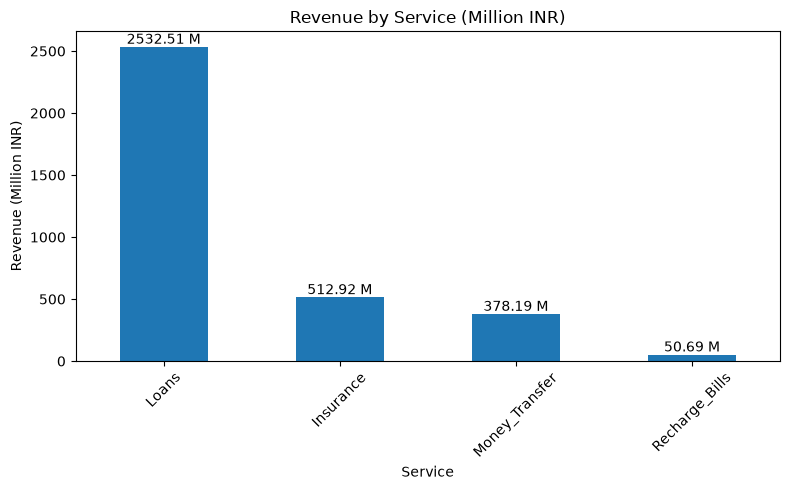

In [102]:
import matplotlib.pyplot as plt

# Revenue in Millions

service_revenue = (
    df.groupby("SERVICE")["AMOUNT"]
    .sum()/1000000
).sort_values(ascending=False)

# Create Plot

ax = service_revenue.plot(
    kind="bar",
    figsize=(8,5)
)

# Title and Labels

plt.title("Revenue by Service (Million INR)")
plt.xlabel("Service")
plt.ylabel("Revenue (Million INR)")
plt.xticks(rotation=45)

# Labels on Bars

for i, value in enumerate(service_revenue):
    ax.text(
        i,
        value,
        f"{value:.2f} M",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [105]:
service_transactions = (

    df.groupby("SERVICE")
    ["TRANSACTION_ID"]
    .count()

).sort_values(
    ascending=False
)


print("="*50)
print("     TRANSACTIONS BY SERVICE")
print("="*50)

print(service_transactions)

     TRANSACTIONS BY SERVICE
SERVICE
Money_Transfer    150000
Insurance          50000
Loans              50000
Recharge_Bills     50000
Name: TRANSACTION_ID, dtype: int64


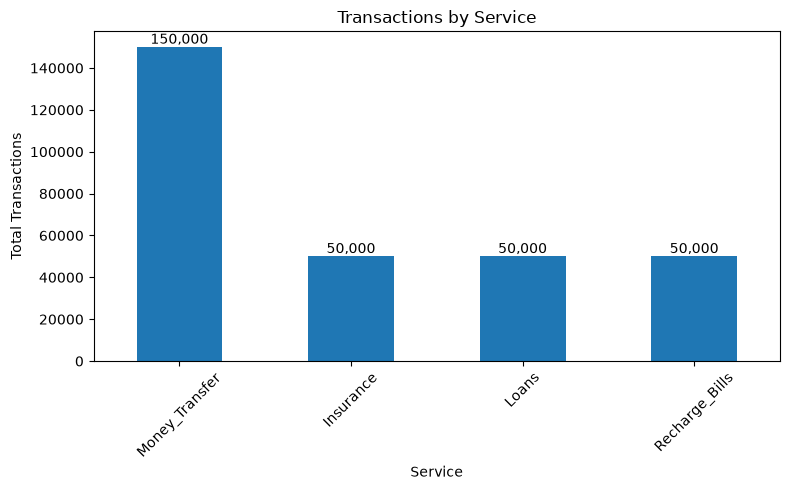

In [106]:
ax = service_transactions.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title(
    "Transactions by Service"
)

plt.xlabel(
    "Service"
)

plt.ylabel(
    "Total Transactions"
)

plt.xticks(rotation=45)


for i,value in enumerate(service_transactions):

    ax.text(
        i,
        value,
        f"{value:,}",
        ha="center",
        va="bottom"
    )


plt.tight_layout()

plt.show()

In [109]:
##Revenue Contribution (%)
revenue_percentage = (

    df.groupby("SERVICE")
    ["AMOUNT"]
    .sum() / df["AMOUNT"].sum())*100


print(
    revenue_percentage
    .round(2)
)

SERVICE
Insurance         14.76
Loans             72.89
Money_Transfer    10.89
Recharge_Bills     1.46
Name: AMOUNT, dtype: float64


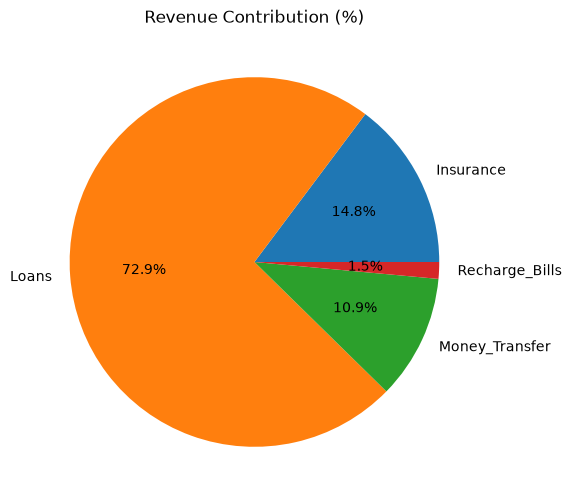

In [110]:
revenue_percentage.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title(
    "Revenue Contribution (%)"
)

plt.ylabel("")

plt.show()

In [111]:
# Highest Revenue Service

print("\nTop Revenue Service\n")

print(
    service_revenue.idxmax()
)

# Lowest Revenue Service

print("\nLowest Revenue Service\n")

print(
    service_revenue.idxmin()
)


Top Revenue Service

Loans

Lowest Revenue Service

Recharge_Bills


                                TIME ANALYSIS

In [112]:
# Yearly Revenue (Million INR)

yearly_revenue = (
    df.groupby("YEAR")["AMOUNT"]
    .sum()/1000000
).sort_values()

print(yearly_revenue)

YEAR
2024    3474.321934
Name: AMOUNT, dtype: float64


In [118]:
# Quarterly Revenue

quarterly_revenue=(

    round(df.groupby("QUARTER")
    ["AMOUNT"]
    .sum()/1000000,2)

)

print(quarterly_revenue)

QUARTER
1    865.03
2    865.96
3    877.61
4    865.72
Name: AMOUNT, dtype: float64


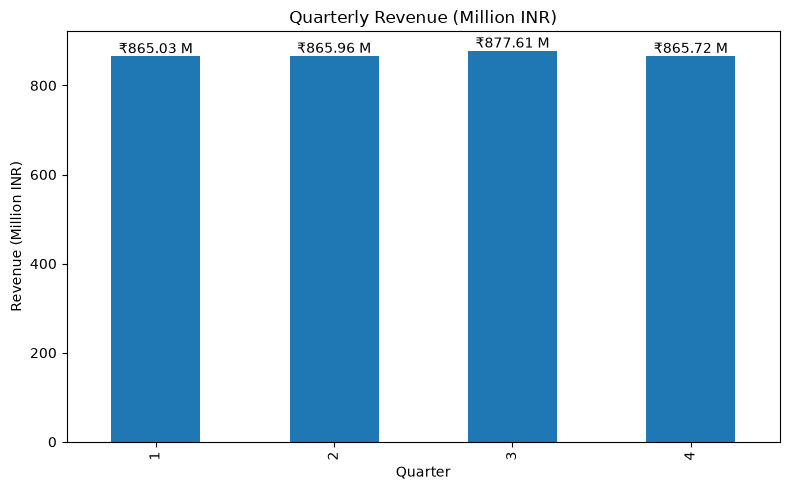

In [120]:
##visual 
ax=quarterly_revenue.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title(
    "Quarterly Revenue (Million INR)"
)

plt.xlabel("Quarter")
plt.ylabel("Revenue (Million INR)")


for i,value in enumerate(quarterly_revenue):

    ax.text(
        i,
        value,
        f"₹{value:.2f} M",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [122]:
# Monthly Revenue

monthly_revenue=(

    round(df.groupby(
        ["MONTH_NO","MONTH_NAME"]
    )["AMOUNT"]

    .sum()/1000000,2)

).reset_index()


print(monthly_revenue)

    MONTH_NO MONTH_NAME  AMOUNT
0          1    January  293.46
1          2   February  278.88
2          3      March  292.70
3          4      April  283.59
4          5        May  296.06
5          6       June  286.32
6          7       July  304.49
7          8     August  290.21
8          9  September  282.91
9         10    October  294.94
10        11   November  284.62
11        12   December  286.16


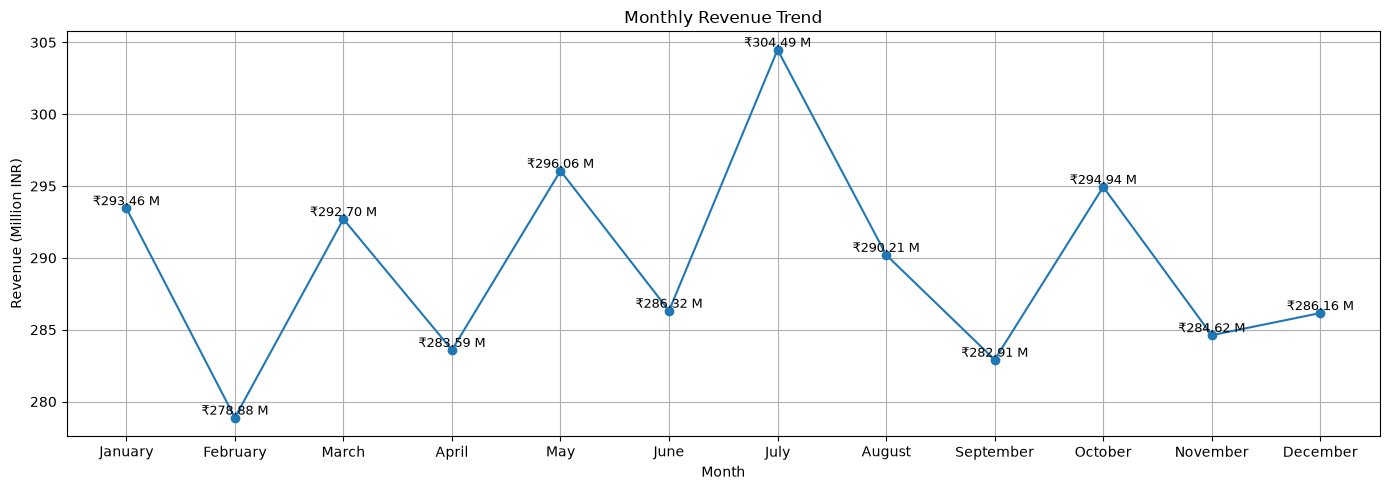

In [125]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

plt.plot(
    monthly_revenue["MONTH_NAME"],
    monthly_revenue["AMOUNT"],
    marker="o"
)

# Adding Labels

for i, value in enumerate(monthly_revenue["AMOUNT"]):
    
    plt.text(
        i,                   # x-position
        value,               # y-position
        f"₹{value:.2f} M",   # label
        ha="center",
        va="bottom",
        fontsize=9
    )


plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (Million INR)")
plt.grid(True)

plt.tight_layout()
plt.show()

In [128]:
# Top 10 Customers

top_10_customers = (

    df.groupby(["USER_ID","USER_NAME"])
    ["AMOUNT"]
    .sum()

).sort_values(
    ascending=False
).head(10)


print("="*60)
print("       TOP 10 CUSTOMERS BY REVENUE ")
print("="*60)

print(top_10_customers.round(2))

       TOP 10 CUSTOMERS BY REVENUE 
USER_ID    USER_NAME          
PP0028780  Jacqueline Cooper      349166.69
PP1075901  Joshua Joseph          341614.07
PP0019432  Bryan Wood             340158.16
PP1073199  Vanessa Wells          339374.81
PP0035403  Sandra Burke           338375.08
PP0048328  Christopher Fleming    336189.81
PP1053341  Daniel Valdez          332905.46
PP0024185  Paige Collins          330492.35
PP1052317  Ryan Wade              328541.64
PP1068113  Paul Harris            327668.62
Name: AMOUNT, dtype: float64


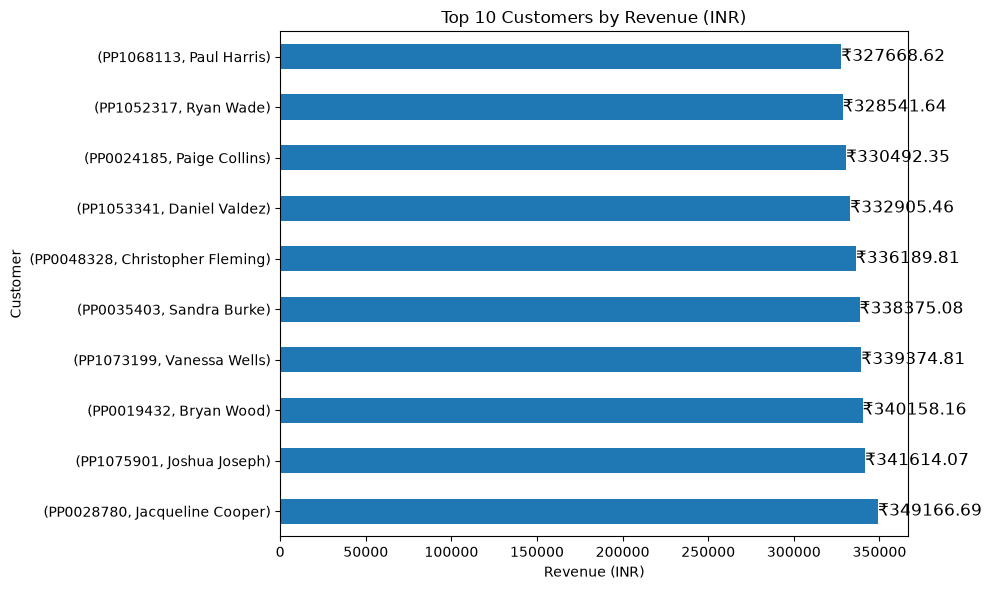

In [132]:
import matplotlib.pyplot as plt

ax = top_10_customers.plot(
    kind="barh",
    figsize=(10,6)
)

plt.title(
    "Top 10 Customers by Revenue (INR)"
)

plt.xlabel(
    "Revenue (INR)"
)

plt.ylabel(
    "Customer"
)


# Labels

for i, value in enumerate(top_10_customers):

    ax.text(
        value,
        i,
        f"₹{value:.2f} ",
        va="center",
        fontsize=12
    )

plt.tight_layout()
plt.show()

In [133]:
##Top 10 Customers by Transactions
# Total Transactions

top_transactions = (

    df.groupby(
    ["USER_ID","USER_NAME"]
    )["TRANSACTION_ID"]

    .count()

).sort_values(
    ascending=False
).head(10)


print(top_transactions)

USER_ID    USER_NAME       
PP0006288  Robert Finley       15
PP1068118  David Dominguez     15
PP1077041  Christopher Lamb    14
PP0018453  Allen Schultz       14
PP0017360  Anthony Clark       14
PP1096081  Jeffrey Castillo    14
PP0017780  Rachel Johns        13
PP0039675  Pamela Powell       13
PP0046540  Pamela Preston      13
PP0045037  Dennis Rich         13
Name: TRANSACTION_ID, dtype: int64


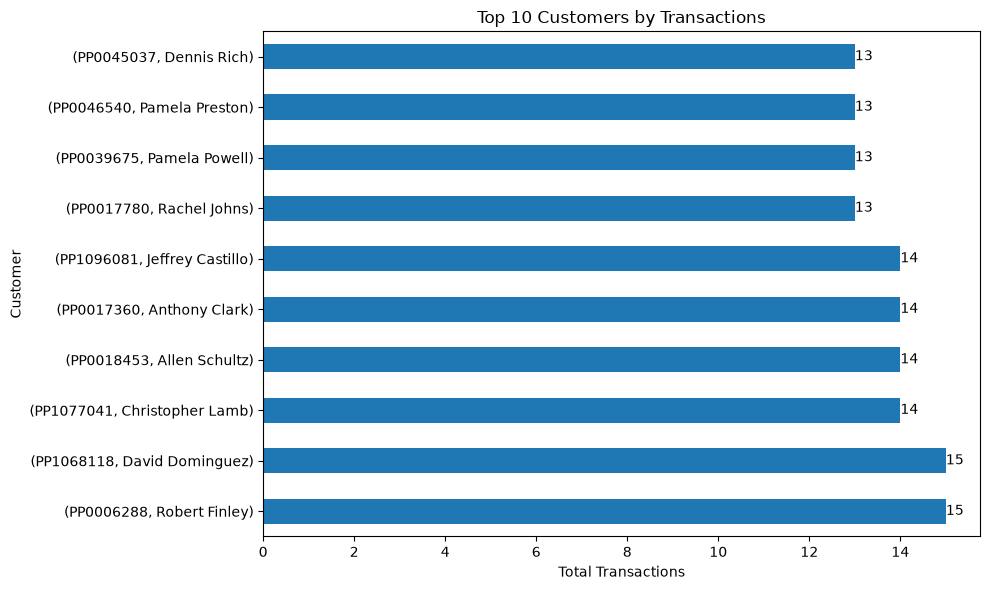

In [134]:
ax = top_transactions.plot(
    kind="barh",
    figsize=(10,6)
)

plt.title(
    "Top 10 Customers by Transactions"
)

plt.xlabel(
    "Total Transactions"
)

plt.ylabel(
    "Customer"
)

for i, value in enumerate(top_transactions):

    ax.text(
        value,
        i,
        f"{value:,}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [136]:
##IQR Method
# Q1

Q1 = df["AMOUNT"].quantile(0.25)

# Median

Q2 = df["AMOUNT"].median()

# Q3

Q3 = df["AMOUNT"].quantile(0.75)

# IQR

IQR = Q3 - Q1


# Lower Bound

lower_bound = (

    Q1 - (1.5*IQR)

)


# Upper Bound

upper_bound = (

    Q3 + (1.5*IQR)

)


print(f"Q1 : {Q1:,.2f}")
print(f"Median : {Q2:,.2f}")
print(f"Q3 : {Q3:,.2f}")
print(f"IQR : {IQR:,.2f}")

print()

print(f"Lower Bound : {lower_bound:,.2f}")
print(f"Upper Bound : {upper_bound:,.2f}")

Q1 : 1,345.59
Median : 3,091.45
Q3 : 8,769.81
IQR : 7,424.22

Lower Bound : -9,790.74
Upper Bound : 19,906.13


In [137]:
# Outlier Transactions

outliers = df[

    (df["AMOUNT"]<lower_bound)

    |

    (df["AMOUNT"]>upper_bound)

]


print("="*50)
print("TOTAL OUTLIERS")
print("="*50)

print(outliers.shape)

TOTAL OUTLIERS
(40779, 18)


In [138]:
print(

len(outliers)

)

40779


In [139]:
# Percentage of Outliers

outlier_percentage = (

    len(outliers)

    /

    len(df)

)*100


print(f"Total Outliers : {len(outliers):,}")

print(f"Outlier Percentage : {outlier_percentage:.2f}%")

Total Outliers : 40,779
Outlier Percentage : 13.59%


In [141]:
df["AMOUNT"].describe()

count    300000.000000
mean      11581.073114
std       21376.115812
min          20.000000
25%        1345.587500
50%        3091.450000
75%        8769.805000
max       99999.010000
Name: AMOUNT, dtype: float64

                       corelation

In [142]:
# Select Required Columns

corr_df = df[[
    "AMOUNT",
    "AGE",
    "YEAR",
    "QUARTER",
    "MONTH_NO",
    "DAY_NO"
]]

In [143]:
# Correlation Matrix

correlation = corr_df.corr()

print(correlation.round(2))

          AMOUNT  AGE  YEAR  QUARTER  MONTH_NO  DAY_NO
AMOUNT       1.0 -0.0   NaN    -0.00     -0.00     0.0
AGE         -0.0  1.0   NaN     0.00      0.00    -0.0
YEAR         NaN  NaN   NaN      NaN       NaN     NaN
QUARTER     -0.0  0.0   NaN     1.00      0.97     0.0
MONTH_NO    -0.0  0.0   NaN     0.97      1.00    -0.0
DAY_NO       0.0 -0.0   NaN     0.00     -0.00     1.0


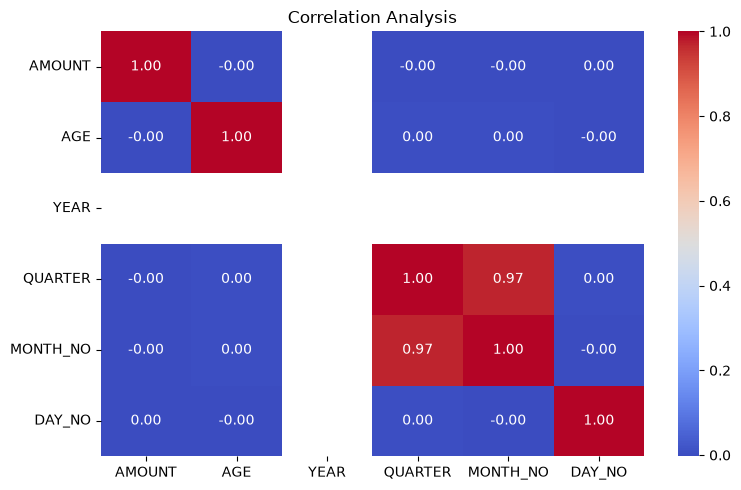

In [144]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Correlation Analysis"
)

plt.tight_layout()

plt.show()

#Correlation Analysis Insights

Quarter and Month Number show a strong positive correlation (0.97), indicating a natural time-based relationship.
Transaction Amount and Age have negligible correlation, suggesting that transaction values are largely independent of customer age.
Most variables exhibit very weak or no linear relationships, indicating that each feature contributes distinct information to the analysis.
No significant multicollinearity was observed among the business variables.

# Final Insights

- Successfully analyzed 300,000 payment transactions across 107,658 users using SQL Server, Python, and Power BI.
- The payment platform achieved a transaction success rate of more than 96%, indicating strong operational performance.
- Loans generated the highest revenue contribution, followed by Insurance and Money Transfer services.
- Revenue remained stable across all four quarters, demonstrating consistent business performance throughout the year.
- Users aged 46–60 contributed the highest revenue, highlighting the importance of high-value customer segments.
- A small percentage of customers generated a significant portion of total revenue, indicating opportunities for customer segmentation and retention strategies.
- Server Errors, Wrong PIN, and Insufficient Amount were identified as the major causes of transaction failures.
- Outlier analysis helped identify unusual transaction patterns that can support fraud detection and transaction monitoring processes.
- Correlation analysis revealed minimal linear relationships among most business variables, with Quarter and Month Number showing a strong positive correlation due to their time-based relationship.
- Data quality validation confirmed the absence of null values, duplicate records, invalid transactions, and referential integrity issues, ensuring reliable analytical reporting.

# Conclusion

This End-to-End PhonePe Payments Analytics project successfully demonstrates industry-standard Data Analytics practices, including ETL processing, data cleaning, data validation, dimensional modeling, statistical analysis, and Business Intelligence reporting. By transforming raw transactional data into actionable insights, the project provides a scalable analytics solution for monitoring payment performance, customer behavior, and business growth. The combination of SQL Server, Python, and Power BI highlights practical expertise in Data Engineering, Data Analytics, Data Warehousing, and Dashboard Development, making this project highly relevant for real-world Data Analyst roles.